# **Mushroom Classification**
## Melissa Tobias
Data 3402 - Spring 2025


---



---



---



# **Define Project**

## This project involves classifying mushrooms as edible or poisonous based on their physical characteristics.
The data was sourced from Kaggle: https://www.kaggle.com/datasets/uciml/mushroom-classification/data.

**The Challenge:**
All features are categorical, and some values may obscure patterns between edible and poisonous mushrooms.

**The Data:**
The dataset includes over 8000 rows and 22 features. The target variable is class:

e = edible

p = poisonous


---



---



---



# **Data Looking and Initial Look**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df=pd.read_csv("mushrooms.csv")
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
# counting rows and features

print(f"Number of rows: {df.shape[0]}")
print(f"Number of features (including target): {df.shape[1]}")

Number of rows: 8124
Number of features (including target): 23


In [ ]:
# missing values, which are labeled as "?"

df.replace("?", pd.NA, inplace=True)
missing_values=df.isna().sum()
print("Missing values after replacing '?':\n", missing_values)

Missing values after replacing '?':
 class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


2480 missing values found, will be removed.


---



---



---



# **Feature Summary Table**

In [ ]:
feature_summary=[]

for col in df.columns:
    col_type="Categorical" if df[col].dtype=="object" else "Numerical"
    unique_vals=df[col].unique()
    num_missing=df[col].isna().sum()

    if col_type=="Categorical":
        value_range=", ".join(sorted(map(str, unique_vals)))[:50]+"..."
    else:
        value_range=f"{df[col].min()} to {df[col].max()}"

    feature_summary.append({
        "Feature": col,
        "Type": col_type,
        "Values": value_range,
        "Missing": num_missing
    })

summary_df=pd.DataFrame(feature_summary)
summary_df

,Feature,Type,Values,Missing
0,class,Categorical,"e, p...",0
1,cap-shape,Categorical,"b, c, f, k, s, x...",0
2,cap-surface,Categorical,"f, g, s, y...",0
3,cap-color,Categorical,"b, c, e, g, n, p, r, u, w, y...",0
4,bruises,Categorical,"f, t...",0
5,odor,Categorical,"a, c, f, l, m, n, p, s, y...",0
6,gill-attachment,Categorical,"a, f...",0
7,gill-spacing,Categorical,"c, w...",0
8,gill-size,Categorical,"b, n...",0
9,gill-color,Categorical,"b, e, g, h, k, n, o, p, r, u, w, y...",0


All features are categorical. Many have a limited number of distinct values, making them suitable for one-hot encoding.

In [ ]:
# dropping all rows that have any missing values

df.dropna(inplace=True)
print("Missing values after dropping:\n", df.isna().sum())

Missing values after dropping:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64




---



---



---

# **Class Balance and Outliers**


## Outlier definition:
An observation that significantly deviates from other observations in the dataset. For numerical features, this might be values far from the mean. In this case, we might treat rare categories as potential anomalies.

In [ ]:
#finding outliers, does not work traditionally since my dataset is purely categorical
#so we are finding rare categories

for col in df.columns:
    print(f"Feature: {col}")
    print(df[col].value_counts(normalize=True).tail())
    print()

Feature: class
class
e    0.618001
p    0.381999
Name: proportion, dtype: float64

Feature: cap-shape
cap-shape
f    0.430900
b    0.053154
k    0.006378
s    0.005670
c    0.000709
Name: proportion, dtype: float64

Feature: cap-surface
cap-surface
y    0.393338
f    0.382707
s    0.223246
g    0.000709
Name: proportion, dtype: float64

Feature: cap-color
cap-color
w    0.155918
e    0.104181
b    0.021262
p    0.017009
c    0.007796
Name: proportion, dtype: float64

Feature: bruises
bruises
t    0.564139
f    0.435861
Name: proportion, dtype: float64

Feature: odor
odor
a    0.070872
l    0.070872
p    0.045358
c    0.034018
m    0.006378
Name: proportion, dtype: float64

Feature: gill-attachment
gill-attachment
f    0.996811
a    0.003189
Name: proportion, dtype: float64

Feature: gill-spacing
gill-spacing
c    0.818568
w    0.181432
Name: proportion, dtype: float64

Feature: gill-size
gill-size
b    0.875266
n    0.124734
Name: proportion, dtype: float64

Feature: gill-color
gill-co

class
e    3488
p    2156
Name: count, dtype: int64


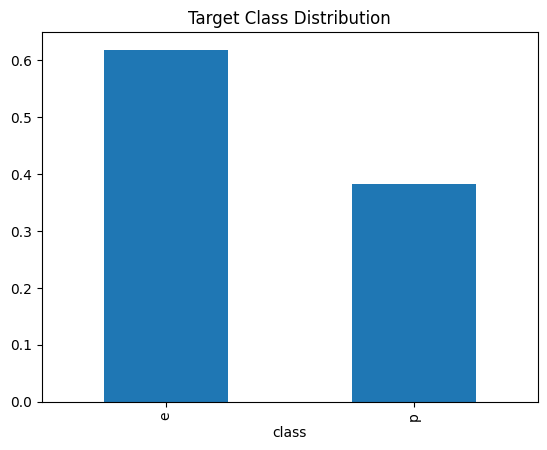

In [ ]:
#class imbalance

df['class'].value_counts(normalize=True).plot(kind='bar', title='Target Class Distribution')
print(df['class'].value_counts())

There is a slightly severe class imbalance: edible and poisonous mushrooms are have a slight gap.



---



---



---


# **Data Visualization**

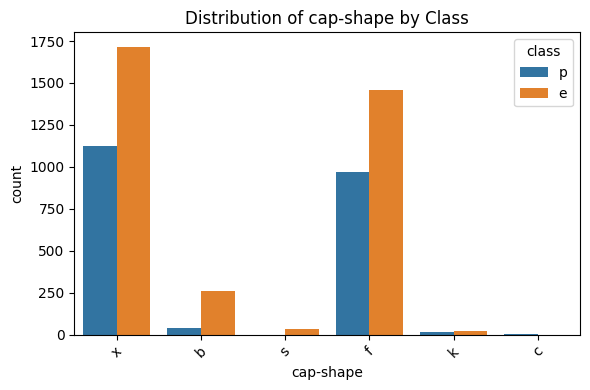

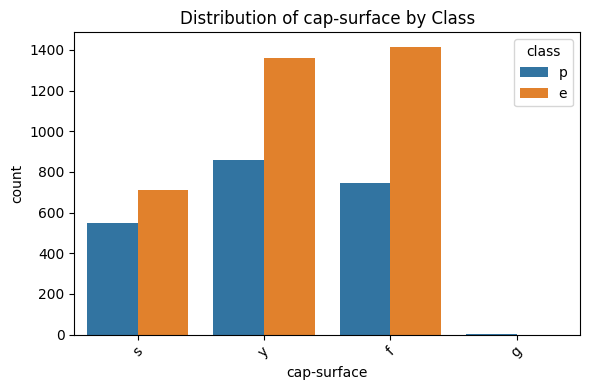

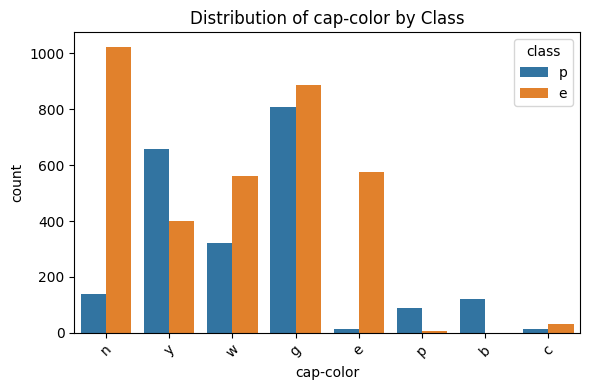

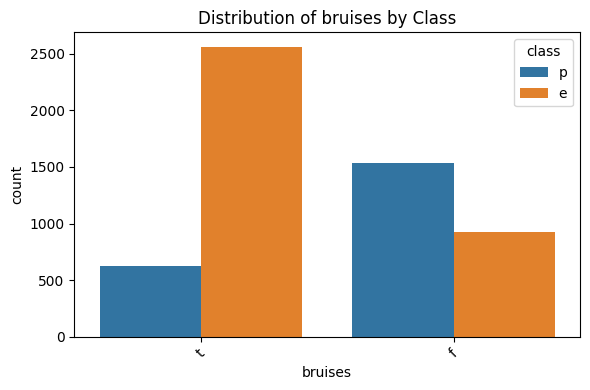

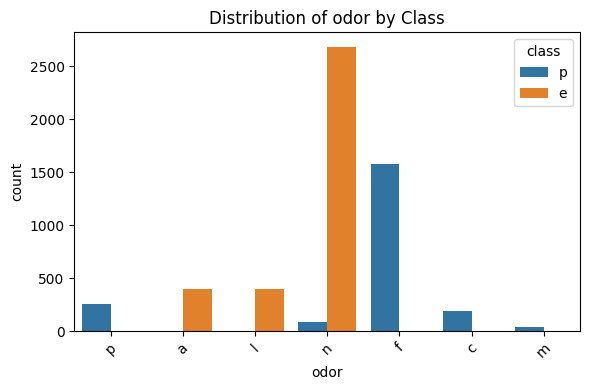

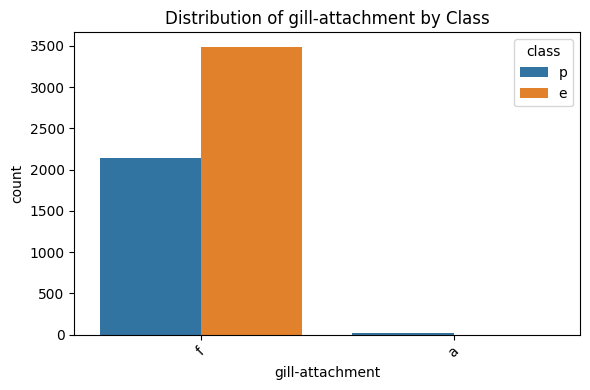

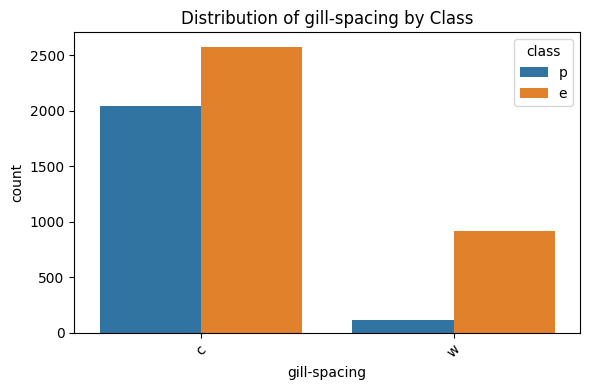

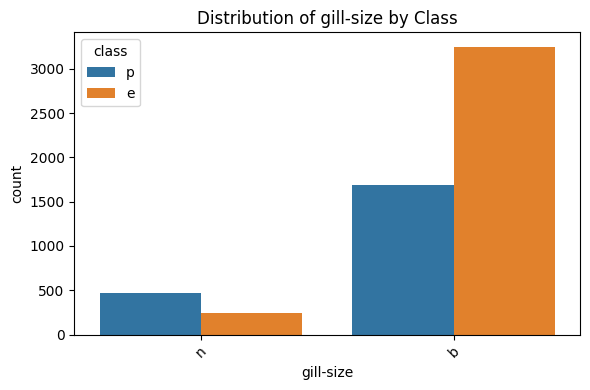

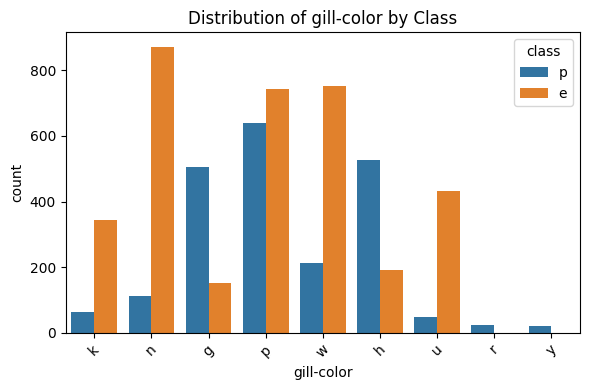

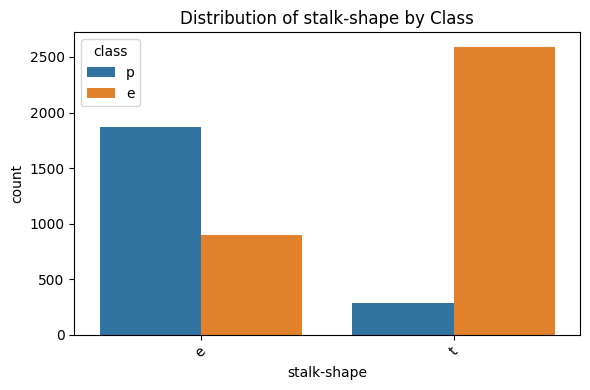

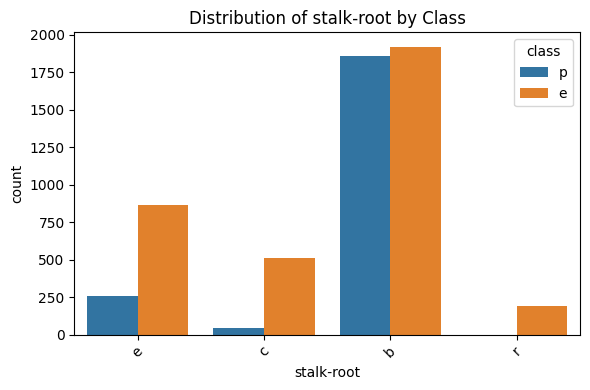

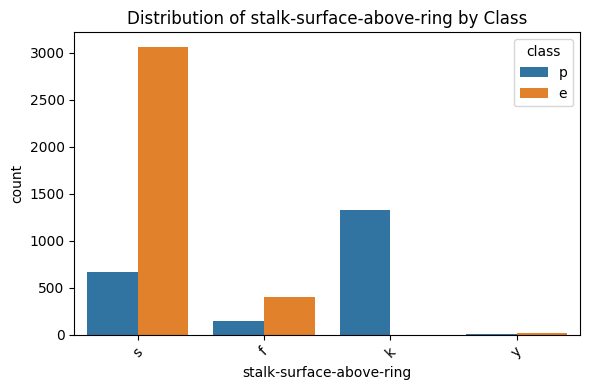

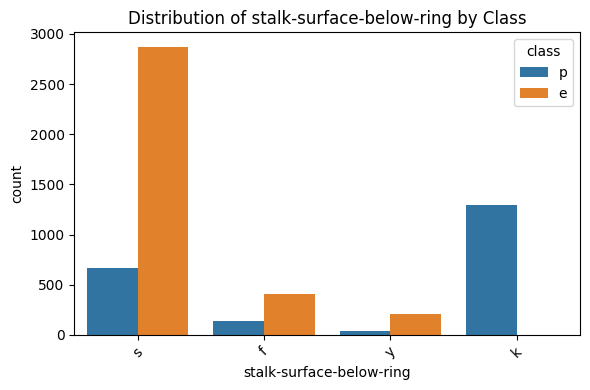

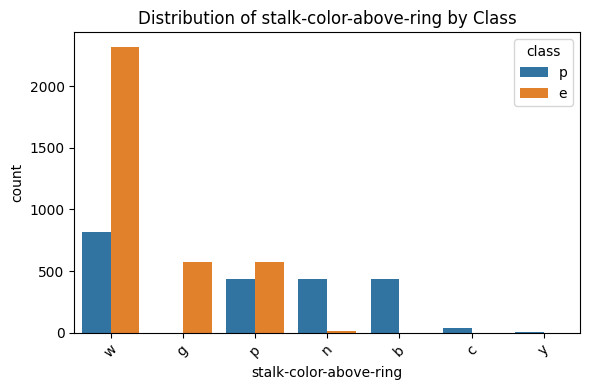

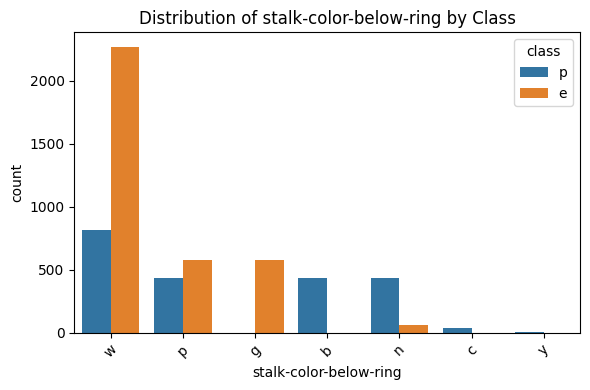

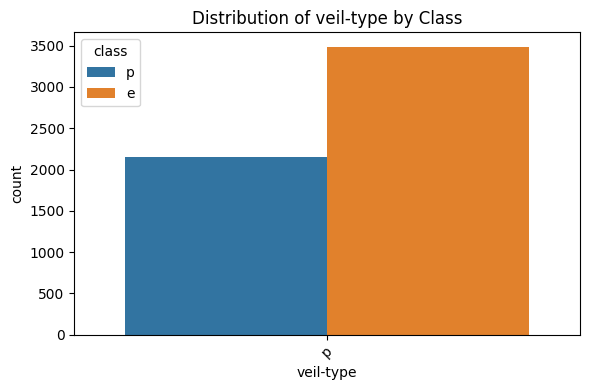

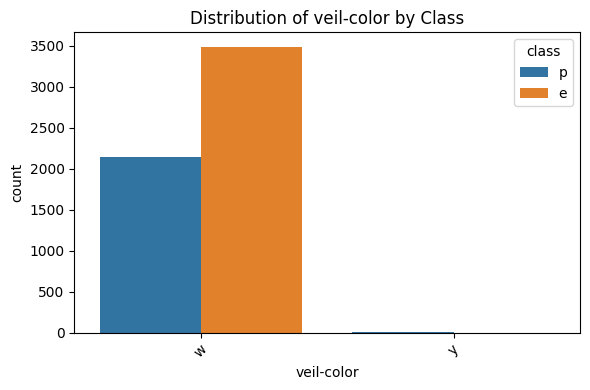

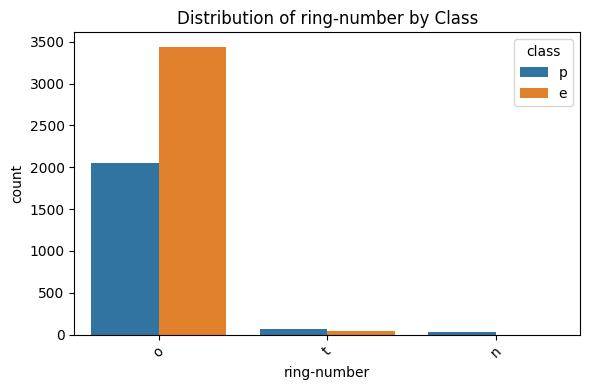

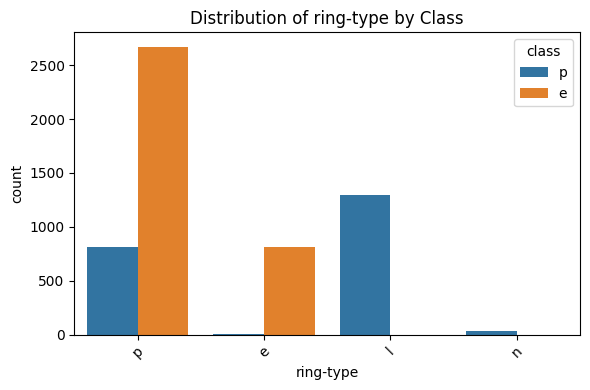

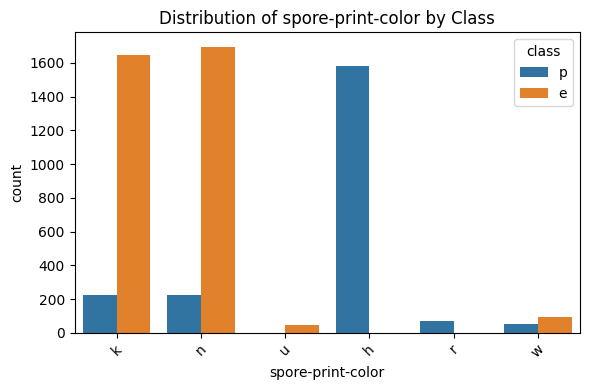

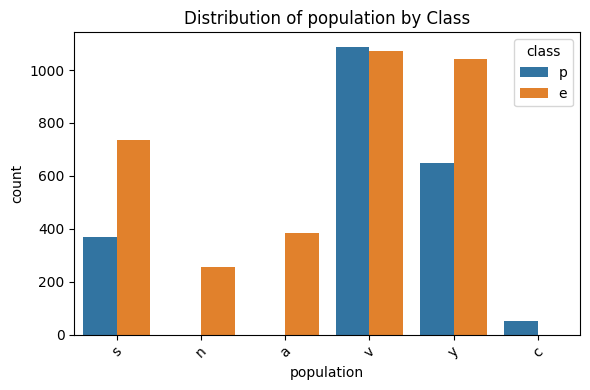

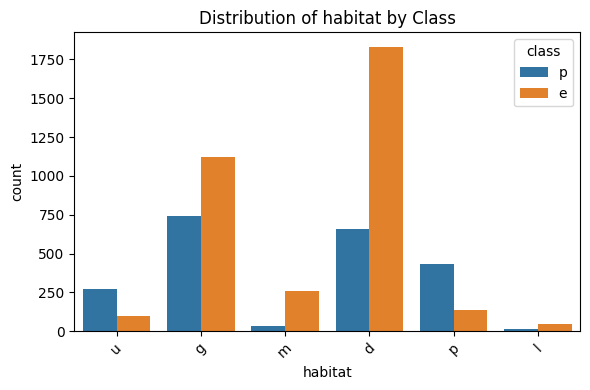

In [ ]:
for column in df.columns[1:]:
    plt.figure(figsize=(6,4))
    sns.countplot(x=column, hue='class', data=df)
    plt.title(f'Distribution of {column} by Class')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Features like odor, spore-print-color, and gill-color show strong separation between edible and poisonous classes, suggesting high predictive potential.


---



---



---



# **Data Cleaning and Preparation**

In [ ]:
# one-hot encode categorical features
X=pd.get_dummies(df.drop('class', axis=1))

# encoding target variable
y=df['class'].map({'e': 0, 'p': 1})

# train/test split
X_train, X_temp, y_train, y_temp=train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test=train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train: (3950, 98), Validation: (847, 98), Test: (847, 98)




---



---



---


# **Rescaling (for KNN)**

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)



---



---



---

# **Machine Learning**

In [ ]:
# model 1 random forest (not scaled)

rf=RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
val_preds_rf=rf.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, val_preds_rf))

Random Forest Accuracy: 1.0


In [ ]:
# model 2 KNN (scaled)

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
val_preds_knn = knn.predict(X_val_scaled)
print("KNN Accuracy:", accuracy_score(y_val, val_preds_knn))

KNN Accuracy: 0.9988193624557261




---



---



---

# **Final Test Evaluation**


Random Forest Accuracy: 1.0


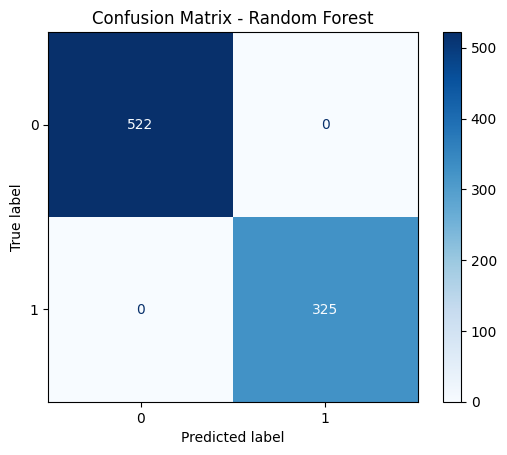


KNN Accuracy: 0.9988193624557261


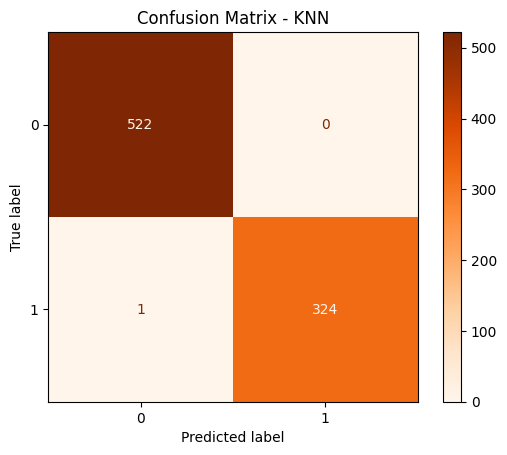

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# random forest
print("\nRandom Forest Accuracy:", accuracy_score(y_val, val_preds_rf))
test_preds_rf=rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_val, val_preds_rf, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()


# KNN
print("\nKNN Accuracy:", accuracy_score(y_val, val_preds_knn))
test_preds_knn=knn.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_val, val_preds_knn, cmap='Oranges')
plt.title("Confusion Matrix - KNN")
plt.show()



---



---



---

# **Submission File**

In [ ]:
submission=pd.DataFrame({
    'Id': np.arange(len(test_preds_rf)),
    'Prediction': test_preds_rf
})
submission.to_csv('submission.csv', index=False)
# e = 0, p = 1